In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
merged = pd.read_csv(
    "final_merged_dataset.csv"
)

merged.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018


In [19]:
def recommend_price(
    occupancy,
    current_price
):

    if occupancy >= 27:
        return current_price * 1.15

    elif occupancy <= 18:
        return current_price * 0.85

    return current_price

In [20]:
merged["recommended_price"] = merged.apply(
    lambda row:
    recommend_price(
        row["occupancy"],
        row["price"]
    ),
    axis=1
)

In [21]:
merged["old_revenue"] = (
    merged["price"]
    *
    merged["demand"]
)

merged["new_revenue"] = (
    merged["recommended_price"]
    *
    merged["demand"]
)

In [22]:
def utilization_zone(x):

    if x >= 27:
        return "High"

    elif x <= 18:
        return "Low"

    return "Medium"

In [23]:
merged["utilization_zone"] = (
    merged["occupancy"]
    .apply(utilization_zone)
)

merged["utilization_zone"].value_counts()

utilization_zone
Medium    6697
Low       1450
High       492
Name: count, dtype: int64

In [24]:
merged["revenue_change"] = (
    merged["new_revenue"]
    -
    merged["old_revenue"]
)

merged["pricing_success"] = (
    merged["revenue_change"] > 0
).astype(int)

merged[
    [
        "revenue_change",
        "pricing_success"
    ]
].head()

,revenue_change,pricing_success
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [25]:
success_rate = (
    merged["pricing_success"]
    .mean()
    * 100
)

print(
    f"Pricing Success Rate: {success_rate:.2f}%"
)

Pricing Success Rate: 5.70%


In [26]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

print(
    f"Old Revenue: {old_rev:.2f}"
)

print(
    f"New Revenue: {new_rev:.2f}"
)

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Old Revenue: 300645.39
New Revenue: 299095.13
Revenue Gain: -0.52%


In [27]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

print(
    f"Old Revenue: {old_rev:.2f}"
)

print(
    f"New Revenue: {new_rev:.2f}"
)

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Old Revenue: 300645.39
New Revenue: 299095.13
Revenue Gain: -0.52%


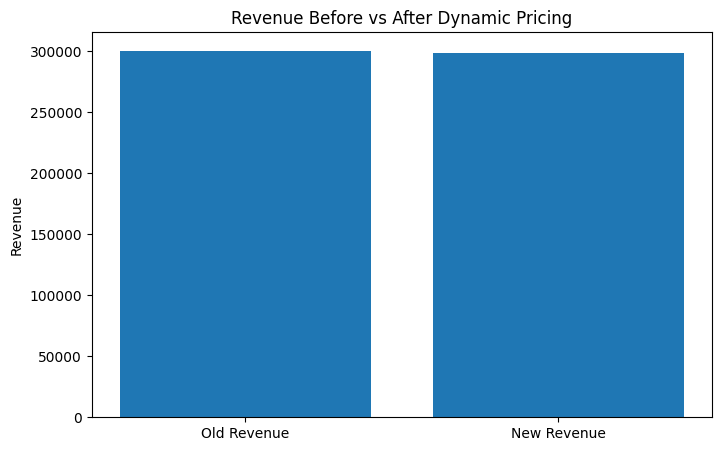

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Old Revenue", "New Revenue"],
    [old_rev, new_rev]
)

plt.title(
    "Revenue Before vs After Dynamic Pricing"
)

plt.ylabel("Revenue")

plt.show()

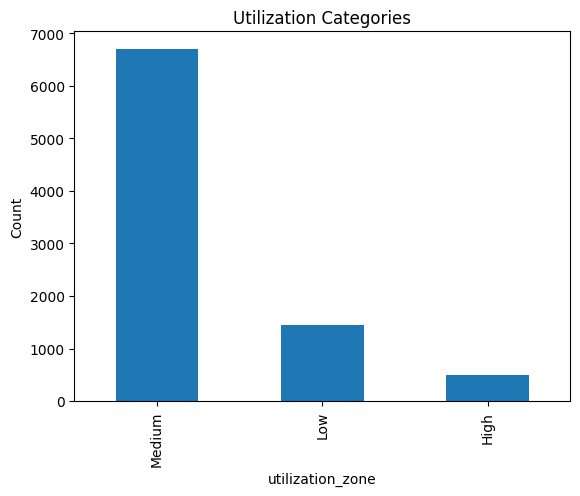

In [29]:
merged[
    "utilization_zone"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Utilization Categories"
)

plt.ylabel(
    "Count"
)

plt.show()

In [30]:
avg_gain = (
    merged["revenue_change"]
    .mean()
)

print(
    f"Average Revenue Change: {avg_gain:.2f}"
)

Average Revenue Change: -0.18


In [31]:
if avg_gain > 0:

    pricing_decision = (
        "Current pricing strategy retained"
    )

else:

    pricing_decision = (
        "Pricing strategy should be revised"
    )

print(pricing_decision)

Pricing strategy should be revised


In [32]:
if avg_gain > 0:

    pricing_decision = (
        "Current pricing strategy retained"
    )

else:

    pricing_decision = (
        "Pricing strategy should be revised"
    )

print(pricing_decision)

Pricing strategy should be revised


In [33]:
merged.to_csv(
    "monitoring_results.csv",
    index=False
)

print(
    "Saved monitoring_results.csv"
)

Saved monitoring_results.csv
